<a href="https://colab.research.google.com/github/camilaalmeiida/wine-quality-classification/blob/main/notebook/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Tech Challenge — Classificação de Qualidade de Vinhos**
**Objetivo**: Desenvolver um modelo de Machine Learning capaz de prever se um vinho é de alta qualidade (nota ≥ 7) ou baixa/média qualidade (nota < 7), com base em suas características físico-químicas.

Pipeline:

Compreensão do Problema

Análise Exploratória de Dados (EDA)

Pré-processamento

Desenvolvimento de Modelos

Avaliação e Comparação

Interpretação dos Resultados

##1. Compreensão do Problema
● Interpretar o contexto do problema.

● Definir claramente a variável alvo.

● Realizar a transformação da variável de qualidade em classificação binária.

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
# Importar os dados da base WineQT, com delimitador do arquivo por virgula
df = pd.read_csv('WineQT.csv', sep= ",")

In [3]:
# Remove a coluna Id pois não tem nenhuma utilidade para o modelo de classificação
df = df.drop(columns=['Id'], errors='ignore')

In [4]:
# Total de linhas e colunas
df.shape

(1143, 12)

In [5]:
# Criação da variavel binaria 1 → Alta Qualidade: nota ≥ 7 e 0 → Baixa/Média Qualidade: nota < 7
df['high_quality'] = (df['quality'] >= 7).astype(int)

In [6]:
# Verificação da distribuição da variável original e da binária criada
print('Distribuição das notas originais de qualidade:')
print(df['quality'].value_counts().sort_index())
print()
print('Distribuição da variável-alvo binária (high_quality):')
print(df['high_quality'].value_counts())
print()

# Percentual de vinhos de acordo com a classe
pct = df['high_quality'].value_counts(normalize=True) * 100
print(f'  Baixa/Média qualidade (0): {pct[0]:.1f}%')
print(f'  Alta qualidade        (1): {pct[1]:.1f}%')

Distribuição das notas originais de qualidade:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Distribuição da variável-alvo binária (high_quality):
high_quality
0    984
1    159
Name: count, dtype: int64

  Baixa/Média qualidade (0): 86.1%
  Alta qualidade        (1): 13.9%


##2. Análise Exploratória de Dados (EDA)
● Investigar a distribuição das variáveis.

● Identificar correlações entre as variáveis e justificar cada uma delas.

● Detectar possíveis outliers ou valores inconsistentes.

● Analisar o balanceamento das classes.

In [7]:
#Descrição do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  high_quality          1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
# Verificar se há valores nulos na base
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [9]:
# Média, desvio padrão, mín, máx e quartis de cada variável
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
count,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000
mean,8.311,0.531,0.268,2.532,0.087,15.615,45.915,0.997,3.311,0.658,10.442,5.657,0.139
std,1.748,0.180,0.197,1.356,0.047,10.250,32.782,0.002,0.157,0.170,1.082,0.806,0.346
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000,0.000
25%,7.100,0.392,0.090,1.900,0.070,7.000,21.000,0.996,3.205,0.550,9.500,5.000,0.000
50%,7.900,0.520,0.250,2.200,0.079,13.000,37.000,0.997,3.310,0.620,10.200,6.000,0.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,61.000,0.998,3.400,0.730,11.100,6.000,0.000
max,15.900,1.580,1.000,15.500,0.611,68.000,289.000,1.004,4.010,2.000,14.900,8.000,1.000


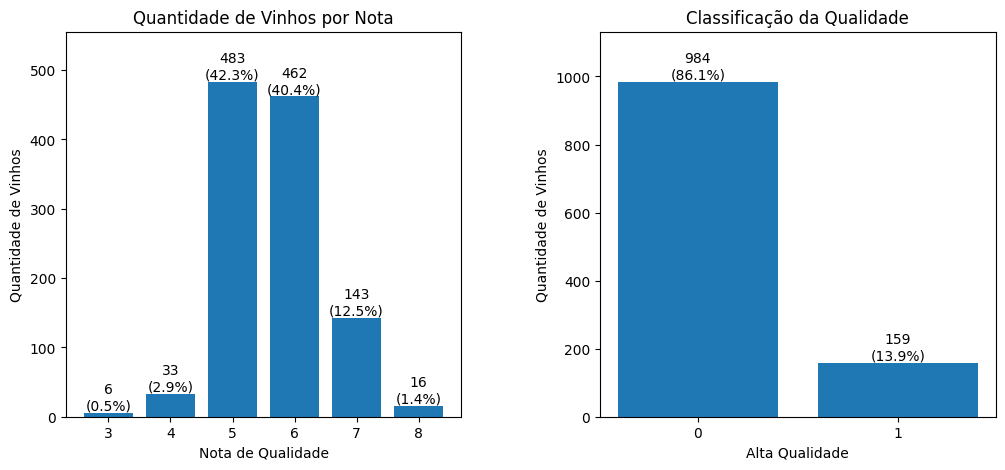

In [10]:
import matplotlib.pyplot as plt
import os

# Contagem das notas originais
notas = df["quality"].value_counts().sort_index()

# Contagem da classificação binária
qtd_notas = df["high_quality"].value_counts().sort_index()

# Criar dois gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- Gráfico 1 ----------------
barras1 = ax[0].bar(notas.index, notas.values)

# Percentuais
percentual1 = notas / notas.sum() * 100

# Rótulos
rotulos1 = [f'{qtd}\n({perc:.1f}%)' for qtd, perc in zip(notas.values, percentual1)]
ax[0].bar_label(barras1, labels=rotulos1)

ax[0].set_xlabel("Nota de Qualidade")
ax[0].set_ylabel("Quantidade de Vinhos")
ax[0].set_title("Quantidade de Vinhos por Nota")

# ---------------- Gráfico 2 ----------------
barras2 = ax[1].bar(qtd_notas.index.astype(str), qtd_notas.values)

# Percentuais
percentual2 = qtd_notas / qtd_notas.sum() * 100

# Rótulos
rotulos2 = [f'{qtd}\n({perc:.1f}%)' for qtd, perc in zip(qtd_notas.values, percentual2)]
ax[1].bar_label(barras2, labels=rotulos2)

ax[1].set_xlabel("Alta Qualidade")
ax[1].set_ylabel("Quantidade de Vinhos")
ax[1].set_title("Classificação da Qualidade")

# Ajustar limite do eixo Y
ax[0].set_ylim(0, max(notas.values) * 1.15)
ax[1].set_ylim(0, max(qtd_notas.values) * 1.15)

# Espaço entre os gráficos
plt.subplots_adjust(wspace=0.35)

# Criar a pasta 'results' se ela não existir
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

#para salvar a imagem do grafico na pasta results
plt.savefig(
    os.path.join(output_dir, "qualidade_vinho.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

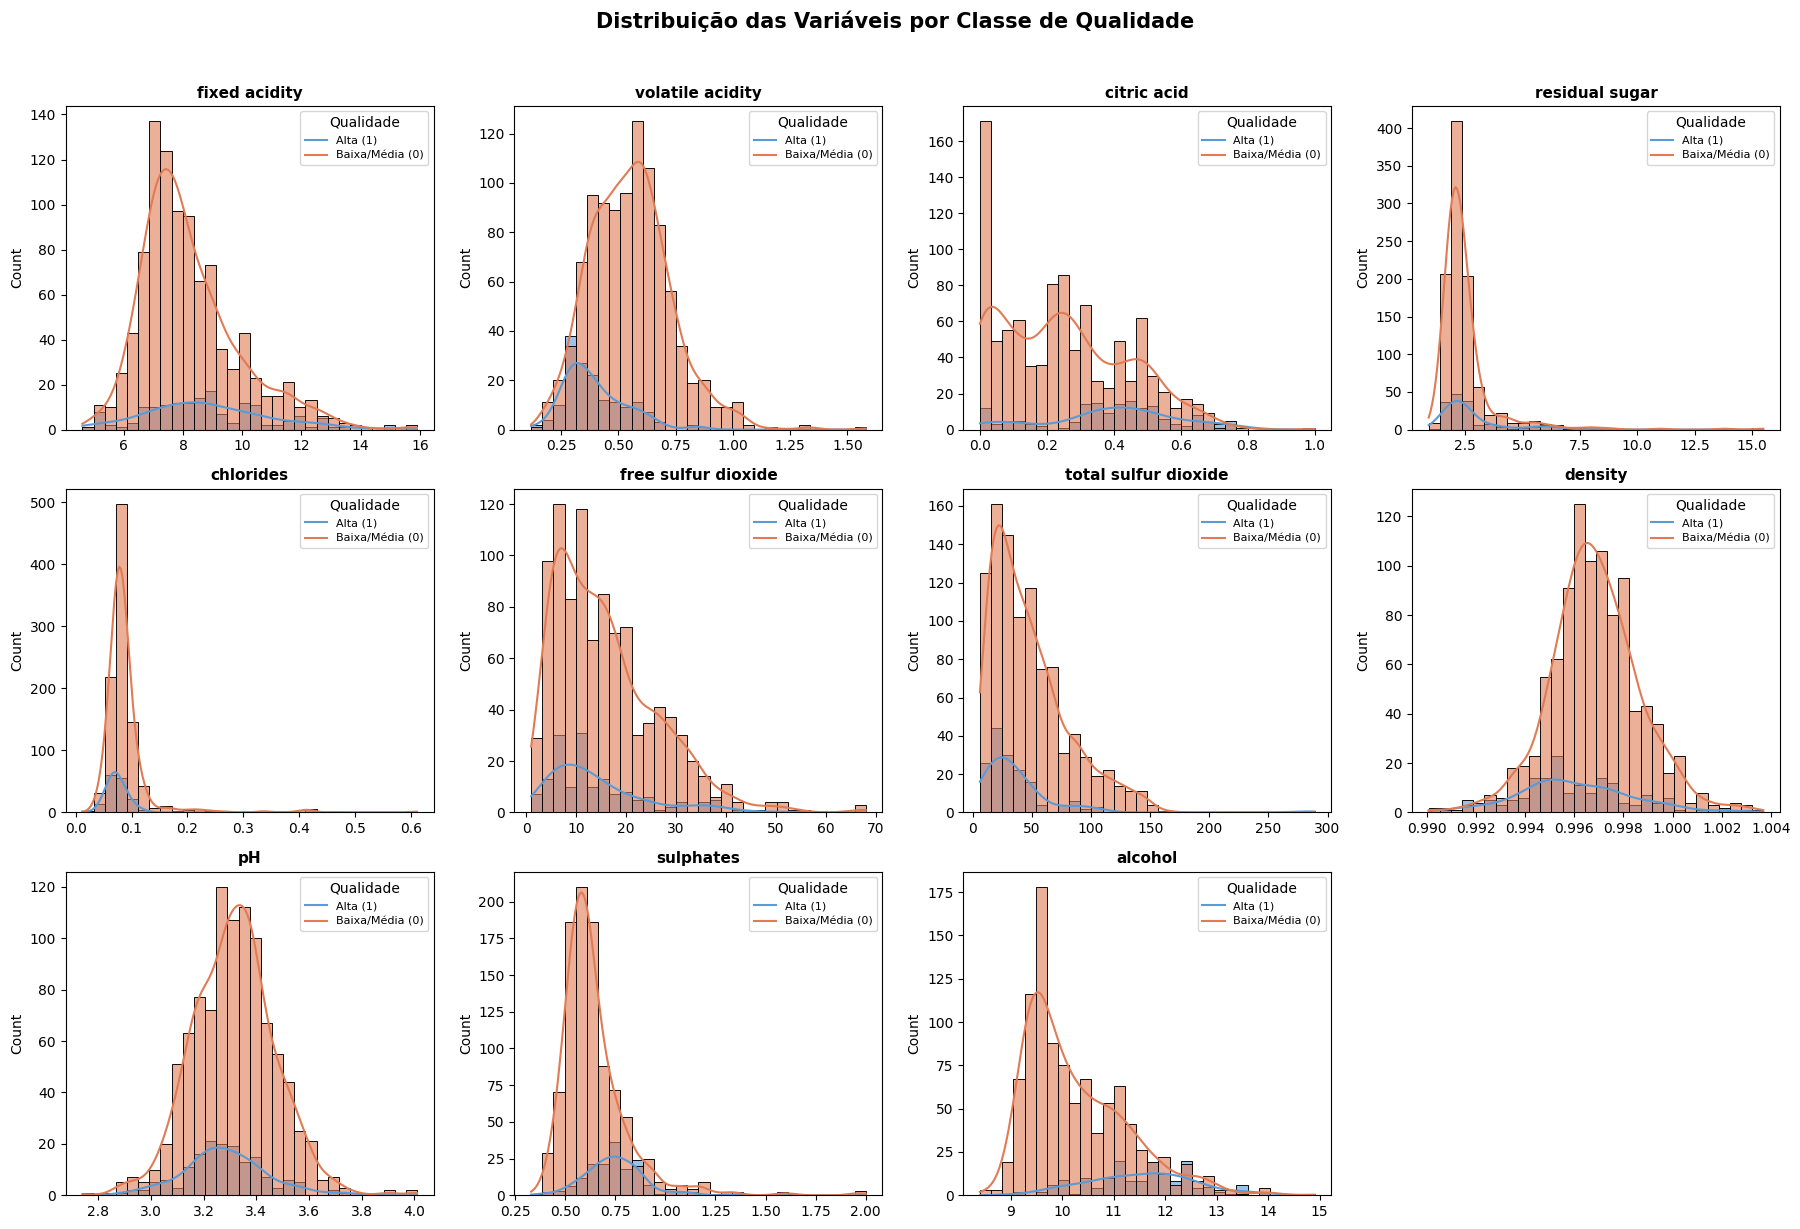

In [11]:
# Histogramas com curva KDE (estimativa de densidade) para entender o formato da distribuição de cada feature.
features = [c for c in df.columns if c not in ['quality', 'high_quality']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # hue='high_quality' mostra como a distribuição difere entre as classes
    sns.histplot(data=df, x=col, hue='high_quality', kde=True, ax=axes[i],
                 palette={0: '#E07B54', 1: '#5B9BD5'}, alpha=0.6, bins=30)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Qualidade', labels=['Alta (1)', 'Baixa/Média (0)'], fontsize=8)

# Remove subplots extras
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

In [12]:
# Identificação de Outliers
# Método: valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR são considerados outliers
print('Quantidade de outliers por variável (método IQR):\n')
outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    outlier_summary[col] = n_out
    print(f'  {col:<28}: {n_out:>4} outliers ({pct_out:.1f}%)')

Quantidade de outliers por variável (método IQR):

  fixed acidity               :   44 outliers (3.8%)
  volatile acidity            :   14 outliers (1.2%)
  citric acid                 :    1 outliers (0.1%)
  residual sugar              :  110 outliers (9.6%)
  chlorides                   :   77 outliers (6.7%)
  free sulfur dioxide         :   18 outliers (1.6%)
  total sulfur dioxide        :   40 outliers (3.5%)
  density                     :   36 outliers (3.1%)
  pH                          :   20 outliers (1.7%)
  sulphates                   :   43 outliers (3.8%)
  alcohol                     :   12 outliers (1.0%)


Optamos por MANTER os outliers, pois em dados de vinho eles podem
   representar características reais de amostras extremas, não erros.
   

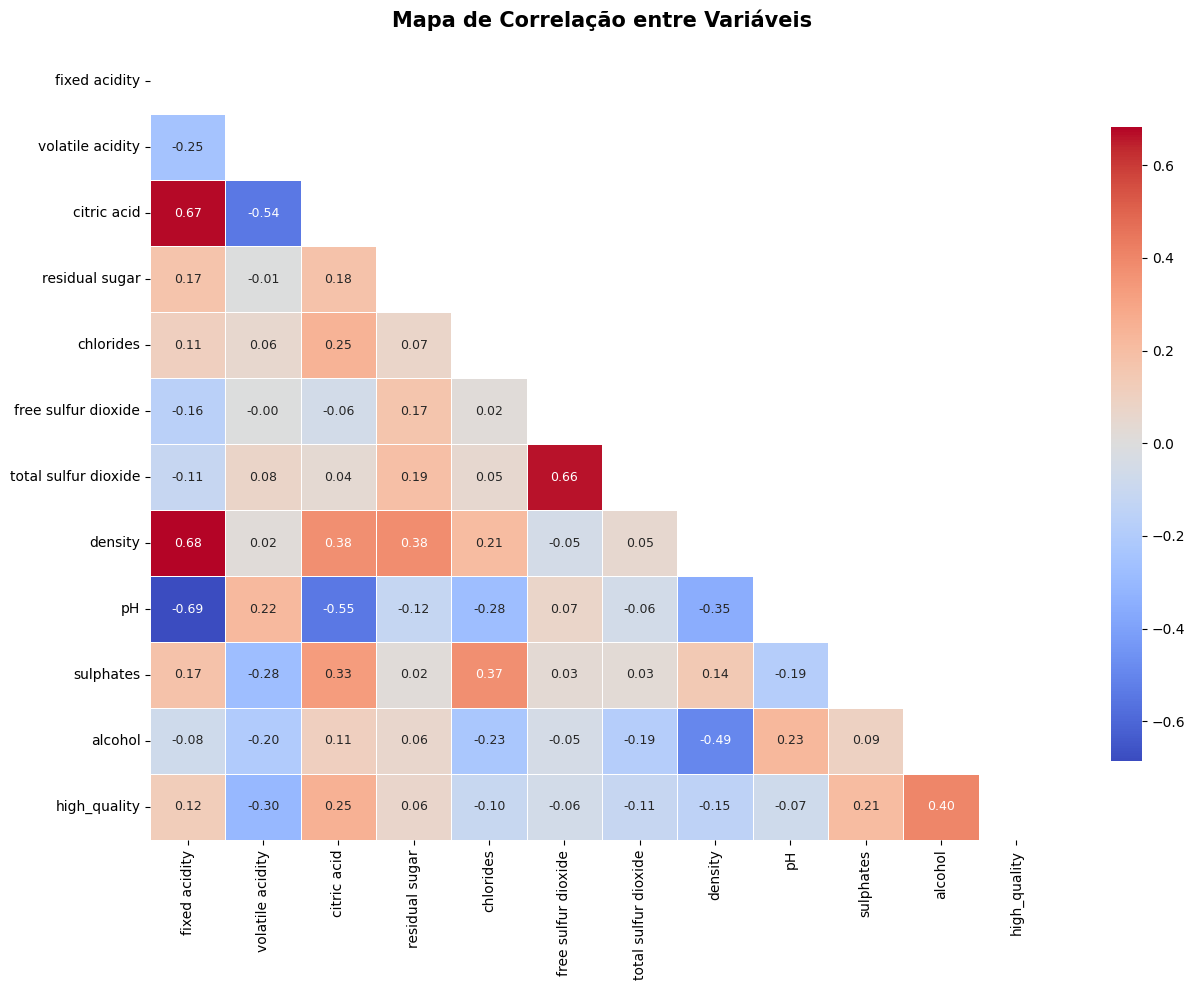


Correlação de cada variável com a qualidade binária (high_quality):
  ▲ alcohol                     : +0.404
  ▼ volatile acidity            : -0.305
  ▲ citric acid                 : +0.251
  ▲ sulphates                   : +0.208
  ▼ density                     : -0.149
  ▲ fixed acidity               : +0.123
  ▼ total sulfur dioxide        : -0.113
  ▼ chlorides                   : -0.104
  ▼ pH                          : -0.073
  ▲ residual sugar              : +0.064
  ▼ free sulfur dioxide         : -0.056


In [13]:
# A correlação de Pearson mede a relação linear entre as variáveis.
# Valores próximos a +1 ou -1 indicam forte correlação.
fig, ax = plt.subplots(figsize=(13, 10))

# Calcula a matriz de correlação (excluindo 'quality' original)
corr_cols = features + ['high_quality']
corr_matrix = df[corr_cols].corr()

# Máscara para ocultar o triângulo superior (evita repetição)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

ax.set_title('Mapa de Correlação entre Variáveis', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Destacar correlações com a variável-alvo
print('\nCorrelação de cada variável com a qualidade binária (high_quality):')
target_corr = corr_matrix['high_quality'].drop('high_quality').sort_values(key=abs, ascending=False)
for var, val in target_corr.items():
    direction = '▲' if val > 0 else '▼'
    print(f'  {direction} {var:<28}: {val:+.3f}')

##3. Pré-processamento de Dados
● Tratamento de dados faltantes (se houver).

● Normalização ou padronização de variáveis numéricas.

● Criação de novas features (feature engineering), se considerado relevante.

In [14]:
# Verificar se há valores nulos na base
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [39]:
# e acidez, que é fundamental para a percepção de qualidade em vinhos
df['alcohol_acidity_ratio'] = df['alcohol'] / (df['fixed acidity'] + df['volatile acidity'] + 1e-6)

# Ratio sulfatos / cloretos — mede o equilíbrio entre conservantes (bons)
# e sal (ruim) no vinho
df['sulphate_chloride_ratio'] = df['sulphates'] / (df['chlorides'] + 1e-6)

# Total de acidez — soma das três componentes ácidas
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

# Razão SO2 livre / total — indica eficiência da proteção por dióxido de enxofre
df['so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)

  Total de features agora: 15 (excluindo quality e high_quality)

  • alcohol_acidity_ratio  — equilíbrio álcool vs acidez

  • sulphate_chloride_ratio — balanço conservante vs sal

  • total_acidity          — acidez total combinada
  
  • so2_ratio              — eficiência do SO2 livre



In [16]:
# Realizar a separação de features (x) e alvo (y)
# Removemos as duas colunas de qualidade: usamos apenas 'high_quality' como alvo
X = df.drop(columns=['quality', 'high_quality'])
y = df['high_quality']

print(f'Features (X): {X.shape[1]} colunas, {X.shape[0]} linhas')
print(f'Alvo     (y): {y.shape[0]} linhas')
print(f'\nColunas usadas como features:')
for col in X.columns:
    print(f'  • {col}')


Features (X): 15 colunas, 1143 linhas
Alvo     (y): 1143 linhas

Colunas usadas como features:
  • fixed acidity
  • volatile acidity
  • citric acid
  • residual sugar
  • chlorides
  • free sulfur dioxide
  • total sulfur dioxide
  • density
  • pH
  • sulphates
  • alcohol
  • alcohol_acidity_ratio
  • sulphate_chloride_ratio
  • total_acidity
  • so2_ratio


In [38]:
#Inicio do treino e teste, será 80/20
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Tamanho do conjunto de treino: {X_train.shape[0]} amostras')
print(f'Tamanho do conjunto de teste:  {X_test.shape[0]} amostras')
print()
print('Proporção das classes no treino:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Proporção das classes no teste:')
print(y_test.value_counts(normalize=True).round(3))

Tamanho do conjunto de treino: 914 amostras
Tamanho do conjunto de teste:  229 amostras

Proporção das classes no treino:
high_quality
0    0.861
1    0.139
Name: proportion, dtype: float64

Proporção das classes no teste:
high_quality
0    0.86
1    0.14
Name: proportion, dtype: float64


Modelos de Machine Learning, quando treinados em dados desbalanceados, tendem a
se tornar enviesados em favor da classe que tem mais dados (majoritária). Isso acontece porque o modelo aprende que a melhor forma de minimizar o erro total é prever a classe majoritária na maioria das vezes, ignorando a classe minoritária. Consequentemente, o modelo terá uma alta acurácia (pois acerta a maioria), mas um péssimo recall e precisão para a classe minoritária, que é geralmente a de maior interesse em muitos problemas

O objetivo é evitar que o modelo classifique indevidamente vinhos de alta qualidade como sendo de baixa/média qualidade, simplesmente por ter poucos exemplos da classe '1' durante o treinamento. Técnicas como o SMOTE (Synthetic Minority Over-sampling Technique) serão aplicadas na fase de pré-processamento para criar amostras sintéticas (referencia: Machine Learning - Guia de Referencia Rapida -  Matt Harrison - O'Reilly) da classe minoritária, ajudando o modelo a aprender melhor as características desta classe.

Isso será tratado na etapa de pré-processamento com SMOTE.

In [37]:
#Balancear as classes
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Antes do SMOTE (treino):')
print(f'  Classe 0: {(y_train == 0).sum()} amostras')
print(f'  Classe 1: {(y_train == 1).sum()} amostras')
print()
print('Depois do SMOTE (treino):')
print(f'  Classe 0: {(y_train_bal == 0).sum()} amostras')
print(f'  Classe 1: {(y_train_bal == 1).sum()} amostras')


Antes do SMOTE (treino):
  Classe 0: 787 amostras
  Classe 1: 127 amostras

Depois do SMOTE (treino):
  Classe 0: 787 amostras
  Classe 1: 787 amostras


SMOTE: Cria novas amostras da classe minoritária até igualar a quantidade da classe majoritária.

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit APENAS no treino — depois aplicamos a mesma transformação no teste
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print(f'  Média pós-escala (deve ser ≈ 0): {X_train_scaled.mean():.6f}')
print(f'  Desvio padrão   (deve ser ≈ 1): {X_train_scaled.std():.6f}')

  Média pós-escala (deve ser ≈ 0): -0.000000
  Desvio padrão   (deve ser ≈ 1): 1.000000


##4. Desenvolvimento de Modelos
Treinar pelo menos dois modelos de classificação, e comparar o desempenho entre eles

Serão utilizados 3 modelos de classificação: Logistic Regression, Random Forest e Gradient Boosting

É necessário testar modelos diferentes de machine learning, em vez de apenas um único melhor método por que não existe almoço grátis em machine learning (ML): Nenhum método vai dominar todos os outros em todos os conjuntos de dados possíveis.

Os modelos que mais se encaixam num apresndizado estatistico com variavel alvo binária em classificação são:

Logistic Regression

Random Forest

Gradient Boosting

Segue breve eplicação dos modelos retirada do livro An Introduction to Statistical Learning de James/Witten/Hastie/Tibshrani/Taylor

Regressão Logística é utilizado para problemas onde a variável alvo (Y) é qualitativa (ou categórica). E é tipicamente usado para prever resultados binários (como "Sim" ou "Não") ao estimar a probabilidade de uma observação pertencer a uma determinada classe

Random Forest é um método do tipo ensemble que utiliza árvores de decisão como seus blocos de construção fundamentais. Ela é considerada uma evolução do método de bagging, introduzindo uma modificação que melhora a precisão ao "decorrelacionar" as árvores

XG Boosting método de ensemble que combina vários "aprendizes fracos" (weak learners), geralmente árvores de decisão pequenas, para gerar um modelo preditivo potente. Ao contrário do bagging, onde as árvores são construídas independentemente, no boosting as árvores são criadas sequencialmente. O diferencial do boosting é que ele "aprende lentamente" porque cada nova árvore é ajustada aos resíduos (erros) do modelo anterior, tentando melhorar o desempenho onde o modelo atual falhais


In [20]:
#Modelo de Regresão Logistica
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0  # Regularização padrão (L2)
)
lr.fit(X_train_scaled, y_train_bal)

#Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,        # Profundidade máxima para evitar overfitting
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1            # Usa todos os núcleos do processador
)
rf.fit(X_train_scaled, y_train_bal)

#Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,  # Taxa de aprendizado
    max_depth=4,
    random_state=RANDOM_STATE
)
gb.fit(X_train_scaled, y_train_bal)

GradientBoostingClassifier(max_depth=4, n_estimators=200, random_state=42)

## **5. Avaliação dos Modelos**
Avaliar os modelos utilizando métricas adequadas. Também deve ser realizada
uma comparação entre os modelos testados.

Vamos utilizar 5 métricas
Accuracy: % de acertos totais — mas enganosa em dados desbalanceados

Precision: dos que previu como Alta Qualidade, quantos realmente são?

Recall: dos vinhos de Alta Qualidade reais, quantos foram identificados?

F1-Score: média harmônica entre Precision e Recall — equilíbrio entre os dois

ROC-AUC: capacidade de distinguir as classes (1.0 = perfeito, 0.5 = aleatório)

In [35]:
# Centraliza o cálculo de todas as métricas para facilitar a comparação entre modelos.
from sklearn.metrics import *
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Avalia um modelo de classificação e retorna um dicionário com métricas.

    Parâmetros:
        model: modelo já treinado
        X_train, y_train: dados de treino
        X_test, y_test: dados de teste
        model_name: nome do modelo (string)
    """
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilidade da classe 1

    # Validação cruzada com 5 folds estratificados no conjunto de treino
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

    metrics = {
        'Modelo':        model_name,
        'Accuracy':      accuracy_score(y_test, y_pred),
        'Precision':     precision_score(y_test, y_pred),
        'Recall':        recall_score(y_test, y_pred),
        'F1-Score':      f1_score(y_test, y_pred),
        'ROC-AUC':       roc_auc_score(y_test, y_proba),
        'F1 CV (média)': cv_scores.mean(),
        'F1 CV (std)':   cv_scores.std(),
    }
    return metrics

# Avalia os três modelos
results = []
for model, name in [(lr, 'Regressão Logística'), (rf, 'Random Forest'), (gb, 'Gradient Boosting')]:
    metrics = evaluate_model(model, X_train_scaled, y_train_bal, X_test_scaled, y_test, name)
    results.append(metrics)

# Cria DataFrame de resultados
results_df = pd.DataFrame(results).set_index('Modelo')
print('\n')

print('TABELA COMPARATIVA DE DESEMPENHO DOS MODELOS')

print(results_df.round(4).to_string())



TABELA COMPARATIVA DE DESEMPENHO DOS MODELOS
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  F1 CV (média)  F1 CV (std)
Modelo                                                                                         
Regressão Logística    0.7991     0.3793  0.6875    0.4889   0.8610         0.8386       0.0172
Random Forest          0.8777     0.5556  0.6250    0.5882   0.8970         0.9261       0.0096
Gradient Boosting      0.9039     0.6667  0.6250    0.6452   0.8936         0.9416       0.0047


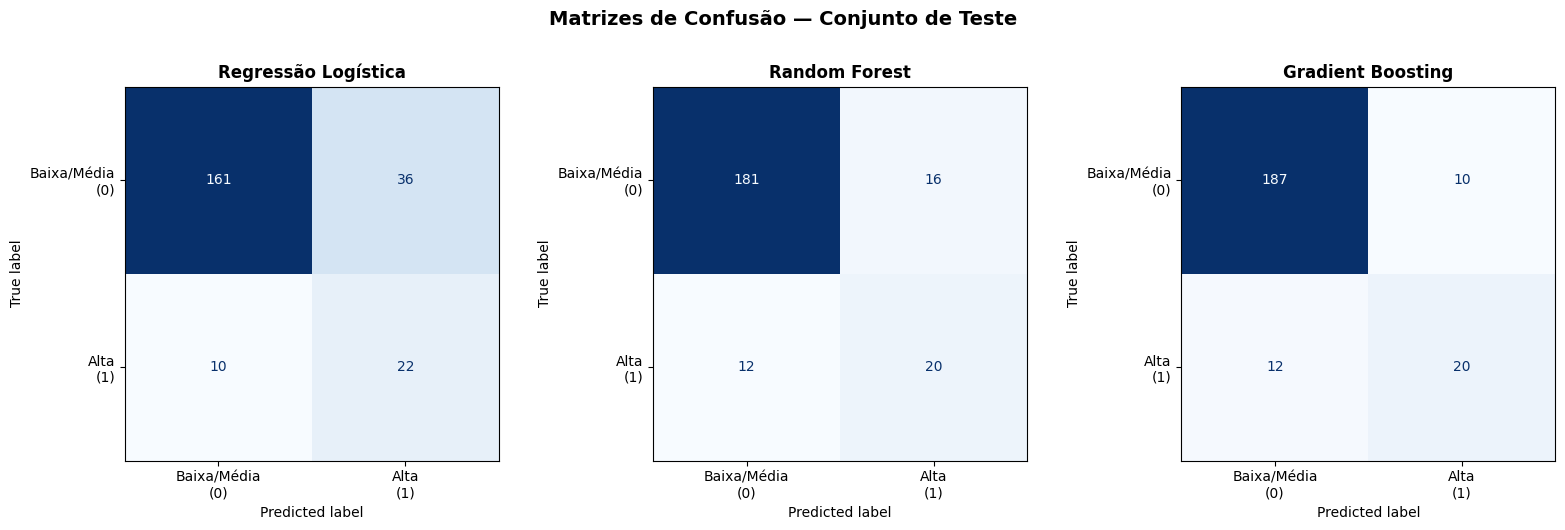

In [22]:
#Matriz de confusão
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_list = [(lr, 'Regressão Logística'), (rf, 'Random Forest'), (gb, 'Gradient Boosting')]

for ax, (model, name) in zip(axes, models_list):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Baixa/Média\n(0)', 'Alta\n(1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

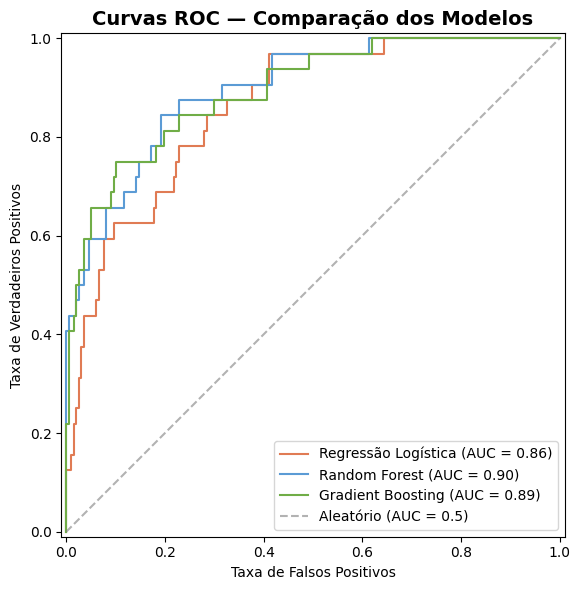

In [23]:
# Curvas ROC a curva ROC plota a Taxa de Verdadeiros Positivos vs a Taxa de Falsos
# Positivos para diferentes limiares de decisão. A área sob a curva
# (AUC) resume o desempenho: 1.0 = perfeito, 0.5 = aleatório.
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#E07B54', '#5B9BD5', '#70AD47']
for (model, name), color in zip(models_list, colors):
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test,
                                   ax=ax, name=name, color=color)

# Linha diagonal = classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6, label='Aleatório (AUC = 0.5)')

ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=14, fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

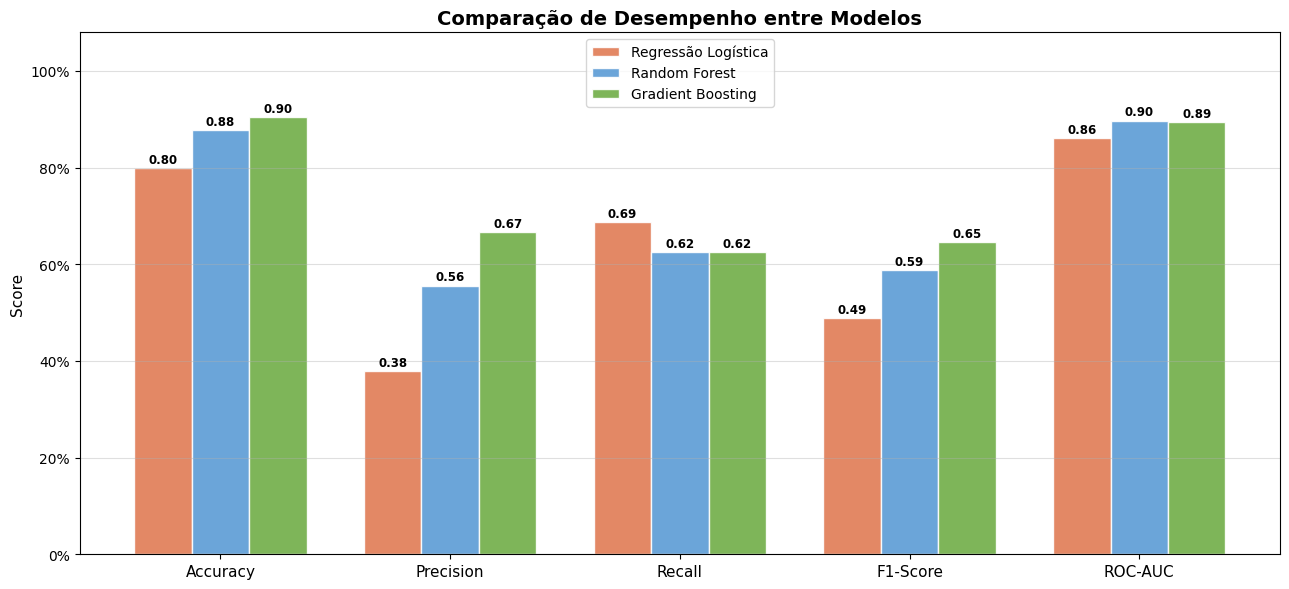

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality,alcohol_acidity_ratio,sulphate_chloride_ratio,total_acidity,so2_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1.160494,7.368324,8.10,0.323529
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,1.129032,6.938705,8.68,0.373134
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,1.144860,7.065141,8.60,0.277778
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,0.853658,7.733230,12.04,0.283333
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1.160494,7.368324,8.10,0.323529
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0,1.166253,7.466567,8.06,0.325000
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0,1.105882,6.666570,8.56,0.254237
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,1,1.257861,7.230658,7.95,0.714286
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,1,1.133651,7.808112,8.40,0.500000
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,0,1.263736,5.566953,7.36,0.230769


In [40]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df[metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 6))

palette = ['#E07B54', '#5B9BD5', '#70AD47']
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model_name,
                  color=palette[i], edgecolor='white', alpha=0.9)
    # Adiciona valor em cima de cada barra
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparação de Desempenho entre Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight')
plt.show()
df.head(10)

Análise do Melhor Modelo

Após comparar os modelos utilizando a métrica F1-Score, o modelo Gradient Boosting apresentou o melhor desempenho e foi escolhido como o modelo final para realizar as previsões.

De acordo com o relatório de classificação, o modelo obteve uma acurácia de 90%, indicando que conseguiu classificar corretamente a maior parte dos registros do conjunto de teste.

Ao analisar cada classe separadamente, observa-se que o desempenho foi melhor para a classe Baixa/Média Qualidade (0). Nessa categoria, o modelo alcançou 94% de precisão, 95% de recall e 94% de F1-Score, mostrando que conseguiu identificar corretamente a maioria dos vinhos dessa classe.

Para a classe Alta Qualidade (1), os resultados foram menores. O modelo obteve 67% de precisão, 62% de recall e 65% de F1-Score. Isso mostra que o modelo teve mais dificuldade para identificar corretamente os vinhos de alta qualidade, deixando de classificar parte deles corretamente.

Essa diferença de desempenho pode estar relacionada ao desbalanceamento dos dados. Enquanto a classe Baixa/Média Qualidade possui 197 registros, a classe Alta Qualidade possui apenas 32 registros. Como o modelo teve mais exemplos da classe majoritária durante o treinamento, ele conseguiu aprender melhor seus padrões.

Além disso, a média ponderada (Weighted Average) apresentou 0,90, enquanto a média simples (Macro Average) foi 0,79. Isso indica que o bom desempenho na classe com maior quantidade de registros influenciou positivamente o resultado geral do modelo.

Conclusão

Com base nos resultados obtidos, o modelo Gradient Boosting foi o que apresentou melhor desempenho entre os modelos avaliados. Embora tenha alcançado uma boa acurácia geral de 90%, ainda existem oportunidades de melhoria na identificação da classe Alta Qualidade.

Para trabalhos futuros, podem ser testadas técnicas para melhorar o desempenho dessa classe, como o balanceamento dos dados, ajuste de hiperparâmetros ou a avaliação de novos modelos. Essas ações podem contribuir para aumentar a capacidade do modelo em identificar corretamente os vinhos de alta qualidade.

  Este modelo oferece o melhor equilíbrio entre precisão e recall
  para identificar vinhos de alta qualidade, minimizando tanto
  falsos positivos quanto falsos negativos no contexto produtivo.
  A consequência mais importante é minimizar falsos positivos
  porque classificar um vinho ruim como bom é altamente prejudicial
  para a marca da empresa, podendo perdurar por meses ou anos.

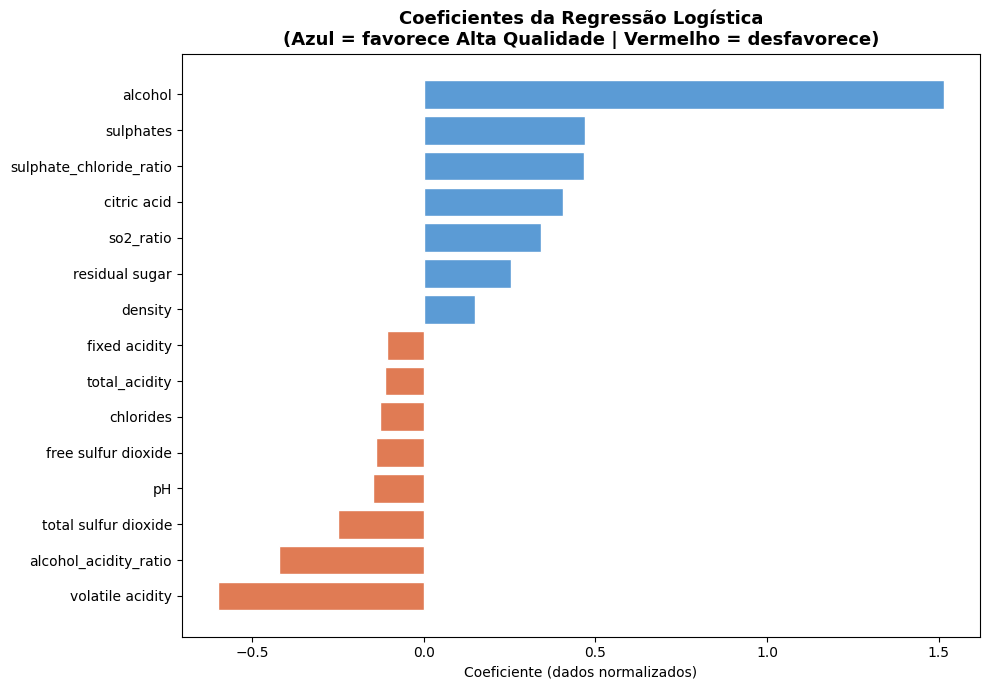

In [27]:
feature_names = X.columns
lr_coefs = pd.Series(lr.coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E07B54' if v < 0 else '#5B9BD5' for v in lr_coefs.values]
bars = ax.barh(lr_coefs.index, lr_coefs.values, color=colors, edgecolor='white')

#ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes da Regressão Logística\n(Azul = favorece Alta Qualidade | Vermelho = desfavorece)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente (dados normalizados)')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

## 6. Interpretação dos Resultados

In [41]:
#Considerações finais
print('Classificação de Qualidade de Vinhos com Machine Learning')
print()
print(' COMPARATIVO FINAL')
print(results_df[['Accuracy', 'F1-Score', 'ROC-AUC']].round(4).to_string())

best_model_name = results_df['F1-Score'].idxmax()
best_row = results_df.loc[best_model_name]
print()
print(f' MODELO VENCEDOR: {best_model_name}')
print(f'   F1-Score : {best_row["F1-Score"]:.2%}')
print(f'   ROC-AUC  : {best_row["ROC-AUC"]:.2%}')
print(f'   Accuracy : {best_row["Accuracy"]:.2%}')

print()
print(' TOP 5 VARIÁVEIS MAIS IMPORTANTES (Random Forest) ')
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
top5 = rf_importances.sort_values(ascending=False).head(5)
for i, (feat, imp) in enumerate(top5.items(), 1):
    print(f'   {i}. {feat:<30}: {imp:.3f}')


Classificação de Qualidade de Vinhos com Machine Learning

 COMPARATIVO FINAL
                     Accuracy  F1-Score  ROC-AUC
Modelo                                          
Regressão Logística    0.7991    0.4889   0.8610
Random Forest          0.8777    0.5882   0.8970
Gradient Boosting      0.9039    0.6452   0.8936

 MODELO VENCEDOR: Gradient Boosting
   F1-Score : 64.52%
   ROC-AUC  : 89.36%
   Accuracy : 90.39%

 TOP 5 VARIÁVEIS MAIS IMPORTANTES (Random Forest) 
   1. alcohol                       : 0.227
   2. sulphates                     : 0.108
   3. citric acid                   : 0.103
   4. volatile acidity              : 0.102
   5. sulphate_chloride_ratio       : 0.078


 **IMPLICAÇÕES PARA A PRODUÇÃO**

   1. ÁLCOOL: A variável mais preditiva. Produtores devem focar em
      processos fermentativos que **maximizem o teor alcoólico**.

   2. ACIDEZ VOLÁTIL: Deve ser monitorada e **mantida baixa**, pois
      está fortemente associada a vinhos de **baixa qualidade**.

   3. SULFATOS: Dentro dos limites seguros, contribuem positivamente.
      Ajustes na dosagem podem elevar a nota percebida do vinho.

   4. O modelo pode ser integrado ao controle de qualidade para
      triar lotes em tempo real, priorizando análise sensorial
      apenas nos casos classificados na fronteira de decisão.